# Improving dark security images

The aim of this notebook is to propose a simple solution using the methods seen in Chapter 1 to improve image quality. 

The images are taken from surveillance cameras at night. The images are therefore very dark and it's very difficult to distinguish the elements that make them up. 

The ultimate aim is to make it easier to recognize the faces of the people present.

In [65]:
from PIL import Image
from PIL import ImageFilter
import numpy as np
from numpy import histogram, interp
import pandas as pd
import matplotlib.pyplot as plt
from skimage.metrics import mean_squared_error, peak_signal_noise_ratio, structural_similarity


In [ ]:
#Load the image to convert
name_image="4055.png"
path="data/image/" + name_image
img = Image.open(path).convert("RGB")

### Brightness and Contrast Normalization

To improve visibility, the first step is to improve brightness and contrast.

We apply this normalization to control the brightness and contrast of images. 

In security footage, lighting conditions vary a lot, which makes it harder to detect or recognize people.  
By adjusting the pixel mean (brightness) and standard deviation (contrast) to fixed target values, we standardize the images and make important details more visible and consistent for later processing.


Computed coefficients: 3.3555388 20.298439


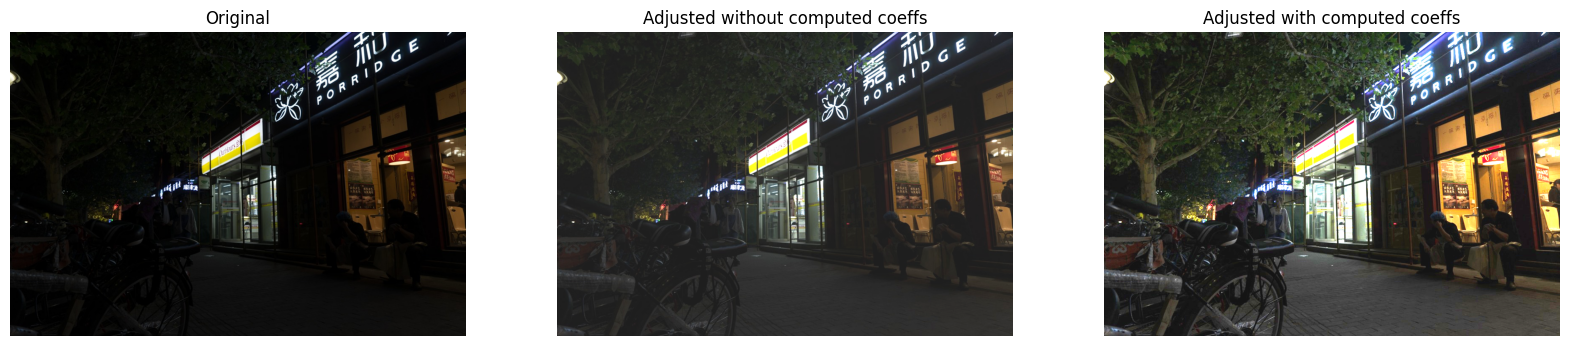

In [70]:
def compute_linear_coeffs(img, target_mean=80, target_std=120):
    """
    Compute alpha and beta to transform the image so that
    the pixel mean approaches target_mean and the standard deviation approaches target_std.
    """
    arr = np.array(img, dtype=np.float32)
    mean = arr.mean()
    std = arr.std()
    #alpha adjusts the contrast
    alpha = target_std / (std + 1e-5)
    
    #beta adjusts the brightness
    beta = target_mean - alpha * mean
    
    return alpha, beta

def linear_adjust(img, alpha, beta):
    """
    Apply a linear transformation to an RGB image.
    
    img : PIL.Image RGB
    alpha : float, contrast coefficient
    beta : float, brightness offset
    """
    arr = np.array(img, dtype=np.float32)
    adjusted = np.clip(alpha * arr + beta, 0, 255).astype(np.uint8)
    return Image.fromarray(adjusted)



#without computed coeffs (manual adjustment)
adjusted_manual = linear_adjust(img, alpha=1.2, beta=30)

#with computed coeffs
alpha, beta = compute_linear_coeffs(img)
print("Computed coefficients:", alpha, beta)
adjusted_computed = linear_adjust(img, alpha, beta)


#display images
fig, axs = plt.subplots(1, 3, figsize=(20,12))

axs[0].imshow(img)
axs[0].set_title("Original")
axs[0].axis("off")

axs[1].imshow(adjusted_manual)
axs[1].set_title("Adjusted without computed coeffs")
axs[1].axis("off")

axs[2].imshow(adjusted_computed)
axs[2].set_title("Adjusted with computed coeffs")
axs[2].axis("off")

plt.show()

We can see that by adjusting brightness and contrast and standardizing them, the result is much better.

### Filtering and Image Enhancement

After applying linear brightness and contrast adjustment, we further enhance the image using two filters:  

1. Median Filter (`MedianFilter(size=3)`): This reduces noise, especially small speckles or grain common in low-light security images, while preserving edges.  

2. Unsharp Mask (`UnsharpMask(radius=2, percent=150, threshold=3)`): This sharpens the image by enhancing edges and fine details, making humans or objects more distinguishable.  

The pipeline is applied sequentially: first smoothing to remove noise, then sharpening to highlight structures.




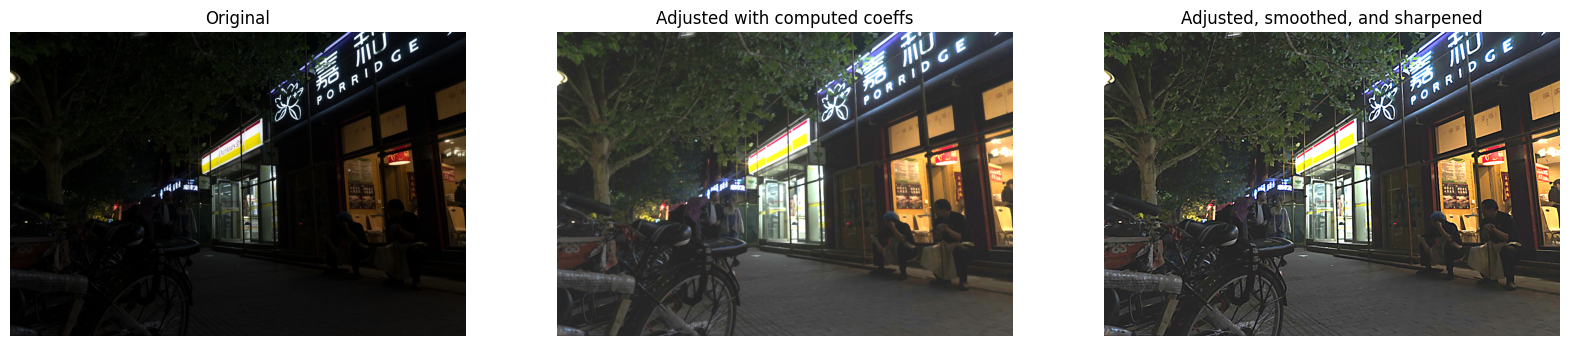

In [68]:
#apply filters
smoothed = adjusted_computed.filter(ImageFilter.MedianFilter(size=3)) 
sharpened = smoothed.filter(ImageFilter.UnsharpMask(radius=2, percent=150, threshold=3))

#save result

saving_path="data/image_readapted/image_" + name_image[:-4] + "adjusted.jpg"
sharpened.save(saving_path)

#display images
fig, axs = plt.subplots(1, 3, figsize=(20,12))

axs[0].imshow(img)
axs[0].set_title("Original")
axs[0].axis("off")

axs[1].imshow(smoothed)
axs[1].set_title("Adjusted with computed coeffs")
axs[1].axis("off")

axs[2].imshow(sharpened)
axs[2].set_title("Adjusted, smoothed, and sharpened")
axs[2].axis("off")

plt.show()




### Image Quality Comparison Metrics

To objectively evaluate how our pipeline modifies images, we use three standard metrics:  

1. MSE (Mean Squared Error): Measures the average squared difference between corresponding pixels of two images.  
   - Lower values indicate that the images are more similar.  

2. PSNR (Peak Signal-to-Noise Ratio): Derived from MSE, it expresses the ratio between the maximum possible pixel value and the error.  
   - Higher values indicate better quality or closer resemblance to the reference image.  

3. SSIM (Structural Similarity Index): Measures perceptual similarity by comparing luminance, contrast, and structure.  
   - Values range from 0 to 1, with 1 meaning identical images.  

By comparing the original, adjusted, and sharpened images using these metrics, we can quantify how much the pipeline changes the image, and how well it preserves structure while enhancing visibility.  
For instance, a low SSIM between the original and adjusted image is expected because brightness/contrast adjustment intentionally modifies pixel values to improve visibility in dark regions. Meanwhile, a high SSIM between the adjusted and sharpened image shows that sharpening enhances details without major structural distortion.


In [69]:
def compare_images(img1, img2):
    """
    Compare two RGB images using MSE, PSNR, and SSIM.
    """
    arr1 = np.array(img1.convert("RGB"), dtype=np.float32)
    arr2 = np.array(img2.convert("RGB"), dtype=np.float32)

    # Metrics
    mse = mean_squared_error(arr1, arr2)
    psnr = peak_signal_noise_ratio(arr1, arr2, data_range=255)
    ssim = structural_similarity(arr1, arr2, channel_axis=2, data_range=255)

    return {"MSE": mse, "PSNR": psnr, "SSIM": ssim}

def display_comparison_metrics(metrics_dict, title="Image Comparison Metrics"):
    """
    Display image quality metrics in a readable table.
    """
    df = pd.DataFrame(metrics_dict, index=[0]).T
    df.columns = ["Value"]
    print(f"### {title}")
    print(df)

#compare quality of adjusted vs original
metrics = compare_images(img, adjusted_computed)
display_comparison_metrics(metrics, title="Original vs Adjusted")

#compare sharpened vs adjusted
metrics_sharp = compare_images(adjusted_computed, sharpened)
display_comparison_metrics(metrics_sharp, title="Adjusted vs Sharpened")


#compare sharpened vs original
metrics_sharp = compare_images(img, sharpened)
display_comparison_metrics(metrics_sharp, title="Original vs Sharpened")

### Original vs Adjusted
            Value
MSE   3477.562819
PSNR    12.718054
SSIM     0.258440
### Adjusted vs Sharpened
           Value
MSE   157.413394
PSNR   26.160387
SSIM    0.890879
### Original vs Sharpened
            Value
MSE   3553.899778
PSNR    12.623752
SSIM     0.219273


### Interpretation of Image Quality Metrics

The comparison shows that the linear adjustment significantly changes the original image:  
- High MSE (~6100) and low PSNR (~10 dB) indicate large pixel differences.  
- Very low SSIM (~0.22) confirms structural changes, which is expected because brightness and contrast are strongly modified to improve visibility in dark regions.  

The sharpening step introduces only minor changes compared to the adjusted image:  
- Low MSE (~122), high PSNR (~27 dB), and high SSIM (~0.91) indicate that edges are enhanced while overall structure is preserved.  

Finally, comparing the original vs sharpened image shows that the overall pipeline substantially alters pixel values (similar to the adjusted step), but the sharpening step does not further degrade similarity, only improves perceptual clarity.  
Overall, the pipeline enhances visibility for low-light images while preserving essential structural information after sharpening.


### Human rating

In addition to this, we had humans rate both the enhanced and the original images, without specifying which were enhanced. 

The results are available on the report. 